## 6.1.3 训练超参数与优化器配置

本节在统一训练环境、损失函数和评价指标已经确定的基础上，配置后续模型训练所使用的超参数与优化策略。

主要任务包括：

1. 继承 6.1.1 中保存的统一运行环境与随机种子；
2. 继承 6.1.2 中确定的损失函数和模型选择指标；
3. 配置批次大小、最大训练轮数、梯度裁剪和早停参数；
4. 为 BaselineCNN 配置统一的完整训练方案；
5. 为 ResNet18Transfer 配置分类头预热、深层特征微调和全模型微调三个阶段；
6. 构建 AdamW 优化器和 ReduceLROnPlateau 学习率调度器；
7. 验证优化器更新、梯度裁剪、学习率衰减和早停程序；
8. 保存后续正式训练可直接读取的统一训练超参数配置。

本节只检查训练策略和相关程序是否能够正确运行，不评价任何模型的真实分类性能。

In [1]:
# ==========================================
# 6.1.3 基础导入、路径定位与结果目录
# ==========================================

# 必须在NumPy和PyTorch导入前设置
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ.setdefault(
    "CUBLAS_WORKSPACE_CONFIG",
    ":4096:8"
)

os.environ.setdefault(
    "PYTHONHASHSEED",
    "42"
)


import sys
import json
import math
import random
import warnings

from pathlib import Path
from datetime import datetime


import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display


warnings.filterwarnings(
    "default"
)


# ------------------------------
# 限制PyTorch线程
# ------------------------------
torch.set_num_threads(
    1
)

try:
    torch.set_num_interop_threads(
        1
    )
except RuntimeError:
    pass


# ------------------------------
# 自动定位项目根目录
# ------------------------------
def find_project_root(
    start_path=None
):
    """
    从当前目录逐层向上搜索项目根目录。

    项目根目录应同时包含：
    EuroSAT_RGB、models和notebooks。
    """

    current_path = (
        Path.cwd()
        if start_path is None
        else Path(start_path).resolve()
    )

    candidate_paths = [
        current_path,
        *current_path.parents
    ]

    for candidate_path in candidate_paths:

        required_paths = [
            candidate_path / "EuroSAT_RGB",
            candidate_path / "models",
            candidate_path / "notebooks"
        ]

        if all(
            path.exists()
            for path in required_paths
        ):
            return candidate_path

    raise FileNotFoundError(
        "未能自动定位项目根目录。\n"
        "请确认项目根目录同时包含："
        "EuroSAT_RGB、models和notebooks。"
    )


PROJECT_ROOT = find_project_root()


# ------------------------------
# 项目目录
# ------------------------------
DATA_DIR = (
    PROJECT_ROOT
    / "EuroSAT_RGB"
)

MODELS_DIR = (
    PROJECT_ROOT
    / "models"
)

NOTEBOOKS_DIR = (
    PROJECT_ROOT
    / "notebooks"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


# ------------------------------
# 前序步骤配置
# ------------------------------
STEP_611_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.1_统一训练环境与随机性控制"
)

STEP_612_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.2_损失函数与评价指标"
)

RUNTIME_CONFIG_PATH = (
    STEP_611_DIR
    / "07_统一训练环境配置.json"
)

EVALUATION_CONFIG_PATH = (
    STEP_612_DIR
    / "10_统一评价配置.json"
)


# ------------------------------
# 当前步骤结果目录
# ------------------------------
STEP_OUTPUT_DIR = (
    RESULTS_DIR
    / "06_模型训练与优化"
    / "6.1.3_训练超参数与优化器配置"
)

STEP_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------
# 中文字体配置
# ------------------------------
font_candidates = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans CN",
    "Arial Unicode MS"
]

available_fonts = {
    font.name
    for font in font_manager.fontManager.ttflist
}

selected_font = next(
    (
        font_name
        for font_name in font_candidates
        if font_name in available_fonts
    ),
    None
)

if selected_font is not None:
    plt.rcParams[
        "font.sans-serif"
    ] = [
        selected_font
    ]

plt.rcParams[
    "axes.unicode_minus"
] = False

plt.rcParams[
    "figure.dpi"
] = 120

plt.rcParams[
    "savefig.dpi"
] = 300

plt.rcParams[
    "axes.titleweight"
] = "bold"

plt.rcParams[
    "axes.labelweight"
] = "bold"


# ------------------------------
# Pandas显示配置
# ------------------------------
pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    180
)

pd.set_option(
    "display.max_colwidth",
    120
)


# ------------------------------
# 路径检查
# ------------------------------
directory_check_df = pd.DataFrame({
    "目录项目": [
        "项目根目录",
        "EuroSAT数据目录",
        "模型目录",
        "6.1.1结果目录",
        "6.1.1统一环境配置",
        "6.1.2结果目录",
        "6.1.2统一评价配置",
        "本步骤结果目录"
    ],
    "绝对路径": [
        str(PROJECT_ROOT),
        str(DATA_DIR),
        str(MODELS_DIR),
        str(STEP_611_DIR),
        str(RUNTIME_CONFIG_PATH),
        str(STEP_612_DIR),
        str(EVALUATION_CONFIG_PATH),
        str(STEP_OUTPUT_DIR)
    ],
    "是否存在": [
        PROJECT_ROOT.exists(),
        DATA_DIR.exists(),
        MODELS_DIR.exists(),
        STEP_611_DIR.exists(),
        RUNTIME_CONFIG_PATH.exists(),
        STEP_612_DIR.exists(),
        EVALUATION_CONFIG_PATH.exists(),
        STEP_OUTPUT_DIR.exists()
    ]
})


print(
    "6.1.3 项目路径定位完成。"
)

print(
    f"项目根目录：{PROJECT_ROOT}"
)

print(
    f"本步骤结果目录：{STEP_OUTPUT_DIR}"
)

if selected_font is not None:
    print(
        f"当前绘图中文字体：{selected_font}"
    )
else:
    print(
        "警告：未找到预设中文字体。"
    )


display(
    directory_check_df
)


assert directory_check_df[
    "是否存在"
].all(), (
    "部分前序配置文件或必要目录不存在。"
)

6.1.3 项目路径定位完成。
项目根目录：d:\qy\junior\深度学习\课设
本步骤结果目录：d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.3_训练超参数与优化器配置
当前绘图中文字体：Microsoft YaHei


,目录项目,绝对路径,是否存在
0,项目根目录,d:\qy\junior\深度学习\课设,True
1,EuroSAT数据目录,d:\qy\junior\深度学习\课设\EuroSAT_RGB,True
2,模型目录,d:\qy\junior\深度学习\课设\models,True
3,6.1.1结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制,True
4,6.1.1统一环境配置,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.1_统一训练环境与随机性控制\07_统一训练环境配置.json,True
5,6.1.2结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标,True
6,6.1.2统一评价配置,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.2_损失函数与评价指标\10_统一评价配置.json,True
7,本步骤结果目录,d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.3_训练超参数与优化器配置,True


In [2]:
# ==========================================
# 6.1.3 读取并继承前序统一配置
# ==========================================

with open(
    RUNTIME_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    runtime_config = json.load(
        file
    )


with open(
    EVALUATION_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:
    evaluation_config = json.load(
        file
    )


GLOBAL_SEED = int(
    runtime_config[
        "随机种子"
    ]
)

DEVICE = torch.device(
    runtime_config[
        "运行设备"
    ]
)

NUM_CLASSES = int(
    evaluation_config[
        "类别数量"
    ]
)

PRIMARY_SELECTION_METRIC = (
    evaluation_config[
        "模型选择首要指标"
    ]
)

AUXILIARY_SELECTION_METRICS = (
    evaluation_config[
        "模型选择辅助指标"
    ]
)


# ------------------------------
# 固定当前Notebook随机性
# ------------------------------
def seed_everything(
    seed
):
    os.environ[
        "PYTHONHASHSEED"
    ] = str(seed)

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed(
            seed
        )

        torch.cuda.manual_seed_all(
            seed
        )


seed_everything(
    GLOBAL_SEED
)


inheritance_config_df = pd.DataFrame({
    "继承项目": [
        "全局随机种子",
        "运行设备",
        "分类类别数量",
        "损失函数",
        "主要模型选择指标",
        "辅助模型选择指标",
        "类别权重",
        "标签平滑系数"
    ],
    "继承结果": [
        GLOBAL_SEED,
        str(DEVICE),
        NUM_CLASSES,
        evaluation_config[
            "损失函数"
        ],
        PRIMARY_SELECTION_METRIC,
        "、".join(
            AUXILIARY_SELECTION_METRICS
        ),
        "不使用",
        evaluation_config[
            "标签平滑系数"
        ]
    ]
})


inheritance_config_path = (
    STEP_OUTPUT_DIR
    / "01_前序配置继承结果.csv"
)

inheritance_config_df.to_csv(
    inheritance_config_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "已读取并继承6.1.1和6.1.2配置。"
)

display(
    inheritance_config_df
)


assert NUM_CLASSES == 10
assert GLOBAL_SEED == 42

已读取并继承6.1.1和6.1.2配置。


,继承项目,继承结果
0,全局随机种子,42
1,运行设备,cpu
2,分类类别数量,10
3,损失函数,CrossEntropyLoss
4,主要模型选择指标,验证集Macro-F1
5,辅助模型选择指标,验证集Accuracy、验证集Loss
6,类别权重,不使用
7,标签平滑系数,0.0


#### 前序配置继承结果分析

本步骤成功读取了 6.1.1 保存的统一运行环境配置和 6.1.2 保存的统一评价配置。当前实验继续使用全局随机种子 42，并在 CPU 设备上运行；分类任务共包含 10 个土地利用类别，损失函数采用 `CrossEntropyLoss`。

模型选择以验证集 Macro-F1 为首要指标，同时参考验证集 Accuracy 和验证集 Loss。该设置与前述评价方案保持一致。Macro-F1 对各类别的 F1 分数进行等权平均，能够避免样本数量较多的类别主导模型选择结果，因此适合作为 EuroSAT 多类别分类任务的主要模型选择依据。

本实验未使用类别权重，标签平滑系数设置为 0。由于数据集虽然存在一定类别数量差异，但分层划分后训练集、验证集和测试集均保持了原始类别结构，因此当前阶段采用普通交叉熵作为统一损失函数是合理的。后续若真实训练结果显示少数类别召回率明显偏低，再考虑引入类别权重或其他类别平衡策略。

综上，本步骤正确继承了前序实验中确定的随机性控制、类别数量、损失函数和模型选择规则，保证后续两个候选模型在相同评价标准下进行训练与比较。

In [3]:
# ==========================================
# 6.1.3 统一训练与优化超参数
# ==========================================

# ------------------------------
# DataLoader相关参数
# ------------------------------
BATCH_SIZE = 32

NUM_WORKERS = 0

PIN_MEMORY = bool(
    DEVICE.type == "cuda"
)

DROP_LAST_TRAIN = False


# ------------------------------
# 优化器参数
# ------------------------------
OPTIMIZER_NAME = "AdamW"

ADAMW_BETAS = (
    0.9,
    0.999
)

ADAMW_EPS = 1e-8


# ------------------------------
# 学习率调度器参数
# ------------------------------
SCHEDULER_NAME = (
    "ReduceLROnPlateau"
)

SCHEDULER_MODE = "max"

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

SCHEDULER_THRESHOLD = 1e-4

MIN_LEARNING_RATE = 1e-6


# ------------------------------
# 梯度与早停参数
# ------------------------------
GRADIENT_CLIP_MAX_NORM = 1.0

EARLY_STOPPING_PATIENCE = 6

EARLY_STOPPING_MIN_DELTA = 1e-4

EARLY_STOPPING_MODE = "max"


# ------------------------------
# 训练过程记录参数
# ------------------------------
SAVE_BEST_ONLY = True

MONITOR_METRIC = "Macro F1"

MIXED_PRECISION_ENABLED = bool(
    DEVICE.type == "cuda"
)

LOG_INTERVAL = 50


common_training_config_df = pd.DataFrame({
    "参数项目": [
        "批次大小",
        "DataLoader工作进程",
        "pin_memory",
        "训练集丢弃末尾不完整批次",
        "优化器",
        "AdamW betas",
        "AdamW eps",
        "学习率调度器",
        "调度监控模式",
        "学习率衰减系数",
        "调度器耐心轮数",
        "最小学习率",
        "梯度裁剪最大范数",
        "早停耐心轮数",
        "早停最小改善量",
        "最佳模型监控指标",
        "混合精度训练"
    ],
    "配置结果": [
        BATCH_SIZE,
        NUM_WORKERS,
        PIN_MEMORY,
        DROP_LAST_TRAIN,
        OPTIMIZER_NAME,
        str(ADAMW_BETAS),
        ADAMW_EPS,
        SCHEDULER_NAME,
        SCHEDULER_MODE,
        SCHEDULER_FACTOR,
        SCHEDULER_PATIENCE,
        MIN_LEARNING_RATE,
        GRADIENT_CLIP_MAX_NORM,
        EARLY_STOPPING_PATIENCE,
        EARLY_STOPPING_MIN_DELTA,
        MONITOR_METRIC,
        MIXED_PRECISION_ENABLED
    ]
})


common_training_config_path = (
    STEP_OUTPUT_DIR
    / "02_统一训练超参数.csv"
)

common_training_config_df.to_csv(
    common_training_config_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "统一训练与优化超参数："
)

display(
    common_training_config_df
)

统一训练与优化超参数：


,参数项目,配置结果
0,批次大小,32
1,DataLoader工作进程,0
2,pin_memory,False
3,训练集丢弃末尾不完整批次,False
4,优化器,AdamW
5,AdamW betas,"(0.9, 0.999)"
6,AdamW eps,0.0
7,学习率调度器,ReduceLROnPlateau
8,调度监控模式,max
9,学习率衰减系数,0.5


In [4]:
# ==========================================
# 6.1.3 两个候选模型的分阶段训练方案
# ==========================================

training_phase_records = [
    {
        "模型名称": "BaselineCNN",
        "训练阶段": "完整训练",
        "阶段编号": "Baseline",
        "最大训练轮数": 30,
        "初始学习率": 1e-3,
        "权重衰减": 1e-4,
        "可训练范围": "全部参数",
        "训练目标": (
            "从随机初始化状态学习"
            "EuroSAT分类特征"
        )
    },
    {
        "模型名称": "ResNet18Transfer",
        "训练阶段": "分类头预热",
        "阶段编号": "A",
        "最大训练轮数": 5,
        "初始学习率": 1e-3,
        "权重衰减": 1e-4,
        "可训练范围": "新分类头",
        "训练目标": (
            "在冻结预训练主干的条件下，"
            "先完成10类别输出适配"
        )
    },
    {
        "模型名称": "ResNet18Transfer",
        "训练阶段": "深层特征微调",
        "阶段编号": "B",
        "最大训练轮数": 10,
        "初始学习率": 1e-4,
        "权重衰减": 1e-4,
        "可训练范围": "Layer4与分类头",
        "训练目标": (
            "调整高层语义特征以适应"
            "遥感土地利用分类"
        )
    },
    {
        "模型名称": "ResNet18Transfer",
        "训练阶段": "全模型微调",
        "阶段编号": "C",
        "最大训练轮数": 15,
        "初始学习率": 1e-5,
        "权重衰减": 1e-4,
        "可训练范围": "全部参数",
        "训练目标": (
            "使用较小学习率联合优化"
            "全部预训练参数"
        )
    }
]


training_phase_df = pd.DataFrame(
    training_phase_records
)


training_phase_path = (
    STEP_OUTPUT_DIR
    / "03_候选模型分阶段训练配置.csv"
)

training_phase_df.to_csv(
    training_phase_path,
    index=False,
    encoding="utf-8-sig"
)


baseline_total_epochs = int(
    training_phase_df.loc[
        training_phase_df[
            "模型名称"
        ] == "BaselineCNN",
        "最大训练轮数"
    ].sum()
)

resnet_total_epochs = int(
    training_phase_df.loc[
        training_phase_df[
            "模型名称"
        ] == "ResNet18Transfer",
        "最大训练轮数"
    ].sum()
)


print(
    "候选模型训练阶段配置："
)

display(
    training_phase_df
)


print(
    f"\nBaselineCNN最大训练轮数："
    f"{baseline_total_epochs}"
)

print(
    f"ResNet18Transfer三个阶段最大总轮数："
    f"{resnet_total_epochs}"
)


assert baseline_total_epochs == 30
assert resnet_total_epochs == 30

候选模型训练阶段配置：


,模型名称,训练阶段,阶段编号,最大训练轮数,初始学习率,权重衰减,可训练范围,训练目标
0,BaselineCNN,完整训练,Baseline,30,0.00100,0.0001,全部参数,从随机初始化状态学习EuroSAT分类特征
1,ResNet18Transfer,分类头预热,A,5,0.00100,0.0001,新分类头,在冻结预训练主干的条件下，先完成10类别输出适配
2,ResNet18Transfer,深层特征微调,B,10,0.00010,0.0001,Layer4与分类头,调整高层语义特征以适应遥感土地利用分类
3,ResNet18Transfer,全模型微调,C,15,0.00001,0.0001,全部参数,使用较小学习率联合优化全部预训练参数



BaselineCNN最大训练轮数：30
ResNet18Transfer三个阶段最大总轮数：30


#### 统一训练超参数与分阶段训练方案分析

统一训练配置中，批次大小设置为 32，`num_workers` 设置为 0，`pin_memory` 设置为 `False`。该配置与当前 CPU 运行环境相匹配，可以避免 Windows 环境下多进程数据加载可能产生的进程启动和随机性问题。训练集不丢弃最后一个不完整批次，因此每个训练周期内的全部样本都能够参与参数更新。

优化器统一采用 AdamW，其一阶矩和二阶矩衰减系数分别为 0.9 和 0.999，数值稳定项为 $10^{-8}$。AdamW 将权重衰减与梯度更新过程相对独立地处理，便于在基础 CNN 和迁移学习模型中使用统一的正则化配置。所有训练阶段的权重衰减均设置为 $10^{-4}$。

学习率调度器采用 `ReduceLROnPlateau`，并以验证集 Macro-F1 为监控指标。由于 Macro-F1 越高表示分类性能越好，因此调度模式设置为 `max`。当验证指标持续停滞时，学习率乘以 0.5，最低学习率限制为 $10^{-6}$。同时启用最大 L2 范数为 1.0 的梯度裁剪，并设置早停耐心轮数为 6，最小有效改善量为 $10^{-4}$。当前设备为 CPU，因此未启用混合精度训练，这与运行环境一致。

BaselineCNN 从随机初始化状态开始训练，全部参数均参与优化，最大训练轮数设置为 30，初始学习率为 $10^{-3}$。该模型作为无预训练权重的基准模型，需要使用相对较高的初始学习率完成全部卷积特征和分类边界的学习。

ResNet18Transfer 采用三个阶段的迁移学习策略。阶段 A 冻结预训练主干，仅训练新建立的 10 类分类头，最大训练 5 轮，学习率为 $10^{-3}$；阶段 B 解冻 Layer4 和分类头，最大训练 10 轮，并将学习率降低至 $10^{-4}$；阶段 C 解冻全部网络参数，最大训练 15 轮，学习率进一步降低至 $10^{-5}$。

三个阶段逐步扩大可训练参数范围，同时逐级降低学习率。这种设计能够先完成新分类头对 EuroSAT 类别的适配，再调整高层语义特征，最后以较小步长联合微调整个预训练网络，从而降低较大学习率对已有 ImageNet 特征的破坏。

BaselineCNN 与 ResNet18Transfer 的最大训练轮数均为 30 轮，使两种方案具有一致的最大 Epoch 预算。需要说明的是，两种模型的参数规模和单轮计算量并不相同，而且早停机制可能使实际训练轮数少于最大值，因此“最大训练轮数相同”不等于两种模型的实际计算成本完全一致。

In [5]:
# ==========================================
# 6.1.3 优化器与学习率调度器构建函数
# ==========================================

def get_trainable_parameters(
    model
):
    """
    返回模型中requires_grad=True的参数。
    """

    return [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]


def count_trainable_parameters(
    model
):
    """
    统计模型当前可训练参数量。
    """

    return int(
        sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )
    )


def build_optimizer(
    model,
    learning_rate,
    weight_decay
):
    """
    为当前可训练参数构建AdamW优化器。
    """

    trainable_parameters = (
        get_trainable_parameters(
            model
        )
    )

    if len(
        trainable_parameters
    ) == 0:
        raise ValueError(
            "当前模型不存在可训练参数。"
        )

    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=float(
            learning_rate
        ),
        betas=ADAMW_BETAS,
        eps=ADAMW_EPS,
        weight_decay=float(
            weight_decay
        )
    )

    return optimizer


def build_scheduler(
    optimizer
):
    """
    构建以验证集Macro-F1为监控指标的
    ReduceLROnPlateau调度器。
    """

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode=SCHEDULER_MODE,
            factor=SCHEDULER_FACTOR,
            patience=SCHEDULER_PATIENCE,
            threshold=SCHEDULER_THRESHOLD,
            threshold_mode="abs",
            min_lr=MIN_LEARNING_RATE
        )
    )

    return scheduler


# ------------------------------
# 创建小型验证模型
# ------------------------------
class OptimizerValidationModel(
    nn.Module
):

    def __init__(
        self,
        input_features=16,
        hidden_features=12,
        num_classes=10
    ):
        super().__init__()

        self.backbone = nn.Sequential(
            nn.Linear(
                input_features,
                hidden_features
            ),
            nn.ReLU()
        )

        self.classifier = nn.Linear(
            hidden_features,
            num_classes
        )

    def forward(
        self,
        x
    ):
        x = self.backbone(
            x
        )

        return self.classifier(
            x
        )


validation_model = (
    OptimizerValidationModel(
        num_classes=NUM_CLASSES
    )
    .to(
        DEVICE
    )
)


validation_optimizer = build_optimizer(
    validation_model,
    learning_rate=1e-3,
    weight_decay=1e-4
)

validation_scheduler = build_scheduler(
    validation_optimizer
)


optimizer_builder_check_df = pd.DataFrame({
    "检查项目": [
        "优化器类型",
        "调度器类型",
        "模型总参数量",
        "模型可训练参数量",
        "参数组数量",
        "初始学习率",
        "权重衰减",
        "调度器监控模式"
    ],
    "检查结果": [
        type(
            validation_optimizer
        ).__name__,
        type(
            validation_scheduler
        ).__name__,
        sum(
            parameter.numel()
            for parameter in validation_model.parameters()
        ),
        count_trainable_parameters(
            validation_model
        ),
        len(
            validation_optimizer.param_groups
        ),
        validation_optimizer.param_groups[
            0
        ][
            "lr"
        ],
        validation_optimizer.param_groups[
            0
        ][
            "weight_decay"
        ],
        SCHEDULER_MODE
    ]
})


optimizer_builder_check_path = (
    STEP_OUTPUT_DIR
    / "04_优化器与调度器构建检查.csv"
)

optimizer_builder_check_df.to_csv(
    optimizer_builder_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "优化器和学习率调度器构建完成："
)

display(
    optimizer_builder_check_df
)


assert isinstance(
    validation_optimizer,
    torch.optim.AdamW
)

assert isinstance(
    validation_scheduler,
    torch.optim.lr_scheduler.ReduceLROnPlateau
)

优化器和学习率调度器构建完成：


,检查项目,检查结果
0,优化器类型,AdamW
1,调度器类型,ReduceLROnPlateau
2,模型总参数量,334
3,模型可训练参数量,334
4,参数组数量,1
5,初始学习率,0.001
6,权重衰减,0.0001
7,调度器监控模式,max


In [6]:
# ==========================================
# 6.1.3 优化器更新与梯度裁剪验证
# ==========================================

seed_everything(
    GLOBAL_SEED
)


update_test_model = (
    OptimizerValidationModel(
        num_classes=NUM_CLASSES
    )
    .to(
        DEVICE
    )
)

update_test_optimizer = build_optimizer(
    update_test_model,
    learning_rate=1e-3,
    weight_decay=1e-4
)

update_test_criterion = (
    nn.CrossEntropyLoss()
)


# ------------------------------
# 构造确定性模拟批次
# ------------------------------
synthetic_inputs = torch.randn(
    32,
    16,
    device=DEVICE
)

synthetic_targets = torch.arange(
    32,
    device=DEVICE
) % NUM_CLASSES


# ------------------------------
# 保存更新前参数
# ------------------------------
parameter_before_update = {
    parameter_name: (
        parameter
        .detach()
        .clone()
    )
    for parameter_name, parameter
    in update_test_model.named_parameters()
}


# ------------------------------
# 前向与反向传播
# ------------------------------
update_test_optimizer.zero_grad(
    set_to_none=True
)

synthetic_logits = update_test_model(
    synthetic_inputs
)

synthetic_loss = update_test_criterion(
    synthetic_logits,
    synthetic_targets
)

synthetic_loss.backward()


# ------------------------------
# 计算裁剪前梯度范数
# ------------------------------
gradient_squared_sum = 0.0

all_gradients_finite = True

for parameter in update_test_model.parameters():

    if parameter.grad is None:
        continue

    if not torch.isfinite(
        parameter.grad
    ).all():
        all_gradients_finite = False

    gradient_squared_sum += float(
        parameter.grad.detach().norm(
            p=2
        ).item() ** 2
    )


gradient_norm_before_clip = math.sqrt(
    gradient_squared_sum
)


# ------------------------------
# 执行梯度裁剪
# ------------------------------
returned_gradient_norm = (
    torch.nn.utils.clip_grad_norm_(
        update_test_model.parameters(),
        max_norm=GRADIENT_CLIP_MAX_NORM
    )
)


gradient_squared_sum_after = 0.0

for parameter in update_test_model.parameters():

    if parameter.grad is None:
        continue

    gradient_squared_sum_after += float(
        parameter.grad.detach().norm(
            p=2
        ).item() ** 2
    )


gradient_norm_after_clip = math.sqrt(
    gradient_squared_sum_after
)


# ------------------------------
# 执行参数更新
# ------------------------------
update_test_optimizer.step()


changed_parameter_count = 0

maximum_parameter_change = 0.0

for parameter_name, parameter in (
    update_test_model.named_parameters()
):

    parameter_change = torch.abs(
        parameter.detach()
        - parameter_before_update[
            parameter_name
        ]
    )

    if float(
        parameter_change.max()
    ) > 0:
        changed_parameter_count += 1

    maximum_parameter_change = max(
        maximum_parameter_change,
        float(
            parameter_change.max()
        )
    )


optimizer_update_check_df = pd.DataFrame({
    "检查项目": [
        "模拟批次损失",
        "损失是否有限",
        "梯度是否全部有限",
        "裁剪前梯度L2范数",
        "裁剪函数返回的原始范数",
        "裁剪后梯度L2范数",
        "梯度裁剪阈值",
        "发生更新的参数张量数量",
        "最大参数绝对变化",
        "参数是否成功更新"
    ],
    "检查结果": [
        float(
            synthetic_loss
        ),
        bool(
            torch.isfinite(
                synthetic_loss
            )
        ),
        all_gradients_finite,
        gradient_norm_before_clip,
        float(
            returned_gradient_norm
        ),
        gradient_norm_after_clip,
        GRADIENT_CLIP_MAX_NORM,
        changed_parameter_count,
        maximum_parameter_change,
        changed_parameter_count > 0
    ]
})


optimizer_update_check_path = (
    STEP_OUTPUT_DIR
    / "05_优化器更新与梯度裁剪检查.csv"
)

optimizer_update_check_df.to_csv(
    optimizer_update_check_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "优化器更新与梯度裁剪检查："
)

display(
    optimizer_update_check_df
)


assert torch.isfinite(
    synthetic_loss
)

assert all_gradients_finite

assert (
    gradient_norm_after_clip
    <= GRADIENT_CLIP_MAX_NORM + 1e-5
)

assert changed_parameter_count > 0

优化器更新与梯度裁剪检查：


C:\Users\lenovo\AppData\Local\Temp\ipykernel_18904\2481773195.py:185: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  float(


,检查项目,检查结果
0,模拟批次损失,2.390977
1,损失是否有限,True
2,梯度是否全部有限,True
3,裁剪前梯度L2范数,0.366812
4,裁剪函数返回的原始范数,0.366812
5,裁剪后梯度L2范数,0.366812
6,梯度裁剪阈值,1.0
7,发生更新的参数张量数量,4
8,最大参数绝对变化,0.001
9,参数是否成功更新,True


#### 优化器构建、参数更新与梯度检查

优化器构建检查使用一个包含 334 个参数的小型验证网络。其中输入层到隐藏层共有

$$
16\times12+12=204
$$

个参数，隐藏层到 10 类输出层共有

$$
12\times10+10=130
$$

个参数，总参数量为

$$
204+130=334
$$

与程序统计结果完全一致。模型中的 334 个参数均处于可训练状态，并被统一加入一个 AdamW 参数组。优化器初始学习率为 0.001，权重衰减为 0.0001；学习率调度器成功构建为 `ReduceLROnPlateau`，监控模式为 `max`。这说明优化器与调度器构建函数能够正确读取当前模型的可训练参数。

在确定性模拟批次中，交叉熵损失为 2.390977，且损失值与全部梯度均为有限数值，没有出现 NaN 或 Inf。对于 10 分类任务，均匀随机预测的理论交叉熵约为

$$
-\log(0.1)=2.302585
$$

当前模拟损失略高于该参考值是正常现象，因为随机初始化网络产生的类别概率并非严格均匀分布。该结果不表示模型性能异常。

反向传播得到的梯度 L2 范数为 0.366812，梯度裁剪函数返回的原始范数同样约为 0.366812，二者相互对应。由于该梯度范数低于设定的裁剪阈值 1.0，因此本次模拟不需要缩放梯度，裁剪前后的梯度范数保持不变。

因此，本次结果能够证明梯度计算正常、裁剪函数调用正常，并且在梯度未超过阈值时不会错误改变梯度。但本次模拟并未真正触发超阈值梯度压缩，因此不能将该结果表述为“梯度已经被裁剪至 1.0”，而应表述为“梯度裁剪机制已接入，本批次梯度未超过裁剪阈值”。

执行 AdamW 更新后，共有 4 个参数张量发生变化，分别对应两个全连接层的权重和偏置；最大参数绝对变化约为 0.00100003，与 $10^{-3}$ 的学习率量级一致。由此可以确认前向传播、损失计算、反向传播、梯度检查和优化器参数更新形成了完整且有效的计算链路。

In [7]:
# ==========================================
# 6.1.3 学习率调度器响应验证
# ==========================================

scheduler_test_model = (
    OptimizerValidationModel(
        num_classes=NUM_CLASSES
    )
    .to(
        DEVICE
    )
)

scheduler_test_optimizer = build_optimizer(
    scheduler_test_model,
    learning_rate=1e-3,
    weight_decay=1e-4
)

scheduler_test_scheduler = build_scheduler(
    scheduler_test_optimizer
)


# 模拟验证集Macro-F1变化
simulated_macro_f1 = [
    0.3000,
    0.4000,
    0.4600,
    0.5000,
    0.5000,
    0.4998,
    0.4997,
    0.5200,
    0.5200,
    0.5198,
    0.5197,
    0.5400
]


scheduler_records = []

previous_learning_rate = float(
    scheduler_test_optimizer.param_groups[
        0
    ][
        "lr"
    ]
)


for epoch_index, metric_value in enumerate(
    simulated_macro_f1,
    start=1
):

    learning_rate_before = float(
        scheduler_test_optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )

    scheduler_test_scheduler.step(
        metric_value
    )

    learning_rate_after = float(
        scheduler_test_optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )

    scheduler_records.append({
        "Epoch": epoch_index,
        "模拟验证集Macro-F1": metric_value,
        "调度前学习率": learning_rate_before,
        "调度后学习率": learning_rate_after,
        "本轮是否降低学习率": (
            learning_rate_after
            < learning_rate_before
        )
    })

    previous_learning_rate = (
        learning_rate_after
    )


scheduler_simulation_df = pd.DataFrame(
    scheduler_records
)


scheduler_simulation_path = (
    STEP_OUTPUT_DIR
    / "06_学习率调度器模拟结果.csv"
)

scheduler_simulation_df.to_csv(
    scheduler_simulation_path,
    index=False,
    encoding="utf-8-sig"
)


learning_rate_reduction_count = int(
    scheduler_simulation_df[
        "本轮是否降低学习率"
    ].sum()
)


print(
    "ReduceLROnPlateau学习率响应验证："
)

display(
    scheduler_simulation_df
)


print(
    f"\n模拟过程中共触发"
    f"{learning_rate_reduction_count}次学习率降低。"
)


assert learning_rate_reduction_count >= 1

assert scheduler_simulation_df[
    "调度后学习率"
].min() >= MIN_LEARNING_RATE

ReduceLROnPlateau学习率响应验证：


,Epoch,模拟验证集Macro-F1,调度前学习率,调度后学习率,本轮是否降低学习率
0,1,0.3000,0.00100,0.00100,False
1,2,0.4000,0.00100,0.00100,False
2,3,0.4600,0.00100,0.00100,False
3,4,0.5000,0.00100,0.00100,False
4,5,0.5000,0.00100,0.00100,False
5,6,0.4998,0.00100,0.00100,False
6,7,0.4997,0.00100,0.00050,True
7,8,0.5200,0.00050,0.00050,False
8,9,0.5200,0.00050,0.00050,False
9,10,0.5198,0.00050,0.00050,False



模拟过程中共触发2次学习率降低。


In [8]:
# ==========================================
# 6.1.3 早停控制器定义与验证
# ==========================================

class EarlyStoppingController:
    """
    基于验证集指标的早停控制器。

    mode='max'：
        指标越大越好，例如Macro-F1。

    mode='min'：
        指标越小越好，例如验证集Loss。
    """

    def __init__(
        self,
        patience=6,
        min_delta=1e-4,
        mode="max"
    ):
        self.patience = int(
            patience
        )

        self.min_delta = float(
            min_delta
        )

        self.mode = mode

        self.best_value = None

        self.bad_epoch_count = 0

        self.should_stop = False

        self.best_epoch = None

    def _is_improvement(
        self,
        current_value
    ):

        if self.best_value is None:
            return True

        if self.mode == "max":

            return (
                current_value
                > self.best_value
                + self.min_delta
            )

        if self.mode == "min":

            return (
                current_value
                < self.best_value
                - self.min_delta
            )

        raise ValueError(
            "mode只能设置为'max'或'min'。"
        )

    def step(
        self,
        current_value,
        epoch
    ):

        if self._is_improvement(
            current_value
        ):

            self.best_value = float(
                current_value
            )

            self.best_epoch = int(
                epoch
            )

            self.bad_epoch_count = 0

            improved = True

        else:

            self.bad_epoch_count += 1

            improved = False

        if (
            self.bad_epoch_count
            >= self.patience
        ):
            self.should_stop = True

        return {
            "是否改善": improved,
            "最佳指标": self.best_value,
            "最佳轮次": self.best_epoch,
            "连续未改善轮数": (
                self.bad_epoch_count
            ),
            "是否触发早停": self.should_stop
        }


# ------------------------------
# 模拟早停过程
# ------------------------------
early_stopping_test_metrics = [
    0.3100,
    0.4200,
    0.5000,
    0.5500,
    0.5500,
    0.5499,
    0.5498,
    0.5497,
    0.5496,
    0.5495,
    0.5494
]


early_stopping_controller = (
    EarlyStoppingController(
        patience=EARLY_STOPPING_PATIENCE,
        min_delta=EARLY_STOPPING_MIN_DELTA,
        mode=EARLY_STOPPING_MODE
    )
)


early_stopping_records = []


for epoch_index, metric_value in enumerate(
    early_stopping_test_metrics,
    start=1
):

    early_stopping_state = (
        early_stopping_controller.step(
            current_value=metric_value,
            epoch=epoch_index
        )
    )

    early_stopping_records.append({
        "Epoch": epoch_index,
        "模拟验证集Macro-F1": metric_value,
        **early_stopping_state
    })

    if early_stopping_state[
        "是否触发早停"
    ]:
        break


early_stopping_simulation_df = pd.DataFrame(
    early_stopping_records
)


early_stopping_simulation_path = (
    STEP_OUTPUT_DIR
    / "07_早停机制模拟结果.csv"
)

early_stopping_simulation_df.to_csv(
    early_stopping_simulation_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "早停机制模拟结果："
)

display(
    early_stopping_simulation_df
)


assert early_stopping_controller.should_stop

assert (
    early_stopping_controller.best_epoch
    == 4
)

早停机制模拟结果：


,Epoch,模拟验证集Macro-F1,是否改善,最佳指标,最佳轮次,连续未改善轮数,是否触发早停
0,1,0.3100,True,0.31,1,0,False
1,2,0.4200,True,0.42,2,0,False
2,3,0.5000,True,0.50,3,0,False
3,4,0.5500,True,0.55,4,0,False
4,5,0.5500,False,0.55,4,1,False
5,6,0.5499,False,0.55,4,2,False
6,7,0.5498,False,0.55,4,3,False
7,8,0.5497,False,0.55,4,4,False
8,9,0.5496,False,0.55,4,5,False
9,10,0.5495,False,0.55,4,6,True


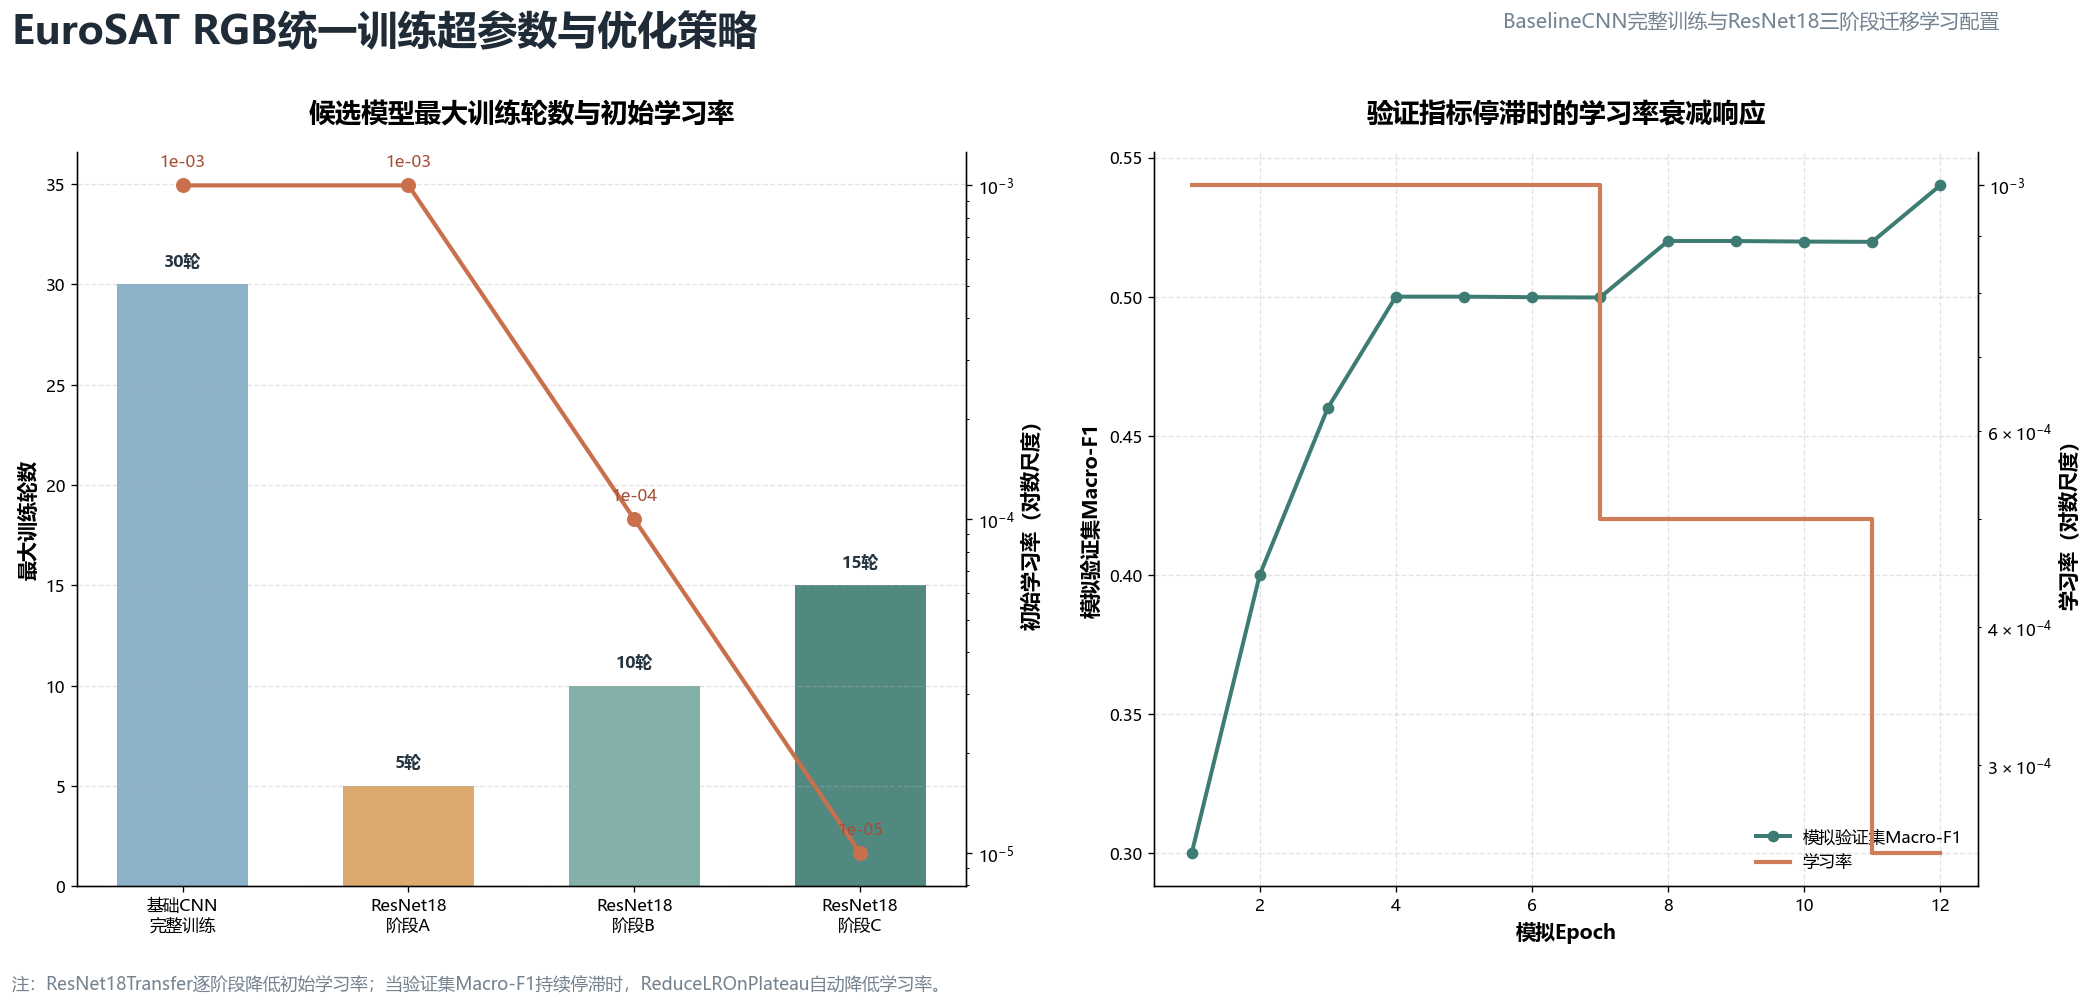

训练策略图已保存：08_训练阶段与学习率调度策略.png


In [9]:
# ==========================================
# 6.1.3 训练阶段与学习率调度可视化
# ==========================================

fig = plt.figure(
    figsize=(18, 9)
)

grid_spec = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[
        1.08,
        1.0
    ],
    left=0.07,
    right=0.95,
    top=0.82,
    bottom=0.14,
    wspace=0.22
)

ax_phase = fig.add_subplot(
    grid_spec[0, 0]
)

ax_scheduler = fig.add_subplot(
    grid_spec[0, 1]
)


# ------------------------------
# 总标题
# ------------------------------
fig.text(
    0.04,
    0.95,
    "EuroSAT RGB统一训练超参数与优化策略",
    fontsize=24,
    fontweight="bold",
    color="#1F2B36",
    va="top"
)

fig.text(
    0.96,
    0.95,
    "BaselineCNN完整训练与ResNet18三阶段迁移学习配置",
    fontsize=12,
    color="#748391",
    ha="right",
    va="top"
)


# ------------------------------
# 左侧：训练阶段配置
# ------------------------------
phase_display_names = [
    "基础CNN\n完整训练",
    "ResNet18\n阶段A",
    "ResNet18\n阶段B",
    "ResNet18\n阶段C"
]

phase_epochs = training_phase_df[
    "最大训练轮数"
].to_numpy()

phase_learning_rates = training_phase_df[
    "初始学习率"
].to_numpy()


phase_x = np.arange(
    len(
        phase_display_names
    )
)


phase_bars = ax_phase.bar(
    phase_x,
    phase_epochs,
    width=0.58,
    alpha=0.90,
    color=[
        "#7EAAC3",
        "#D9A15F",
        "#76A89F",
        "#3E7C73"
    ]
)


for bar, epoch_value in zip(
    phase_bars,
    phase_epochs
):

    ax_phase.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{int(epoch_value)}轮",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#263542"
    )


ax_phase.set_title(
    "候选模型最大训练轮数与初始学习率",
    fontsize=16,
    pad=18
)

ax_phase.set_xticks(
    phase_x
)

ax_phase.set_xticklabels(
    phase_display_names,
    fontsize=10
)

ax_phase.set_ylabel(
    "最大训练轮数",
    fontsize=12
)

ax_phase.set_ylim(
    0,
    max(
        phase_epochs
    ) * 1.22
)

ax_phase.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax_phase.spines[
    "top"
].set_visible(
    False
)


phase_lr_axis = ax_phase.twinx()

phase_lr_axis.plot(
    phase_x,
    phase_learning_rates,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#C96F4C",
    label="初始学习率"
)

phase_lr_axis.set_yscale(
    "log"
)

phase_lr_axis.set_ylabel(
    "初始学习率（对数尺度）",
    fontsize=12
)

phase_lr_axis.spines[
    "top"
].set_visible(
    False
)


for x_value, learning_rate in zip(
    phase_x,
    phase_learning_rates
):

    phase_lr_axis.annotate(
        f"{learning_rate:.0e}",
        xy=(
            x_value,
            learning_rate
        ),
        xytext=(
            0,
            11
        ),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color="#A54E35"
    )


# ------------------------------
# 右侧：学习率调度响应
# ------------------------------
ax_scheduler.plot(
    scheduler_simulation_df[
        "Epoch"
    ],
    scheduler_simulation_df[
        "模拟验证集Macro-F1"
    ],
    marker="o",
    linewidth=2.4,
    color="#3E7C73",
    label="模拟验证集Macro-F1"
)

ax_scheduler.set_title(
    "验证指标停滞时的学习率衰减响应",
    fontsize=16,
    pad=18
)

ax_scheduler.set_xlabel(
    "模拟Epoch",
    fontsize=12
)

ax_scheduler.set_ylabel(
    "模拟验证集Macro-F1",
    fontsize=12
)

ax_scheduler.grid(
    linestyle="--",
    alpha=0.35
)

ax_scheduler.spines[
    "top"
].set_visible(
    False
)


scheduler_lr_axis = (
    ax_scheduler.twinx()
)

scheduler_lr_axis.step(
    scheduler_simulation_df[
        "Epoch"
    ],
    scheduler_simulation_df[
        "调度后学习率"
    ],
    where="post",
    linewidth=2.5,
    color="#D17C58",
    label="学习率"
)

scheduler_lr_axis.set_yscale(
    "log"
)

scheduler_lr_axis.set_ylabel(
    "学习率（对数尺度）",
    fontsize=12
)

scheduler_lr_axis.spines[
    "top"
].set_visible(
    False
)


# ------------------------------
# 合并图例
# ------------------------------
left_lines, left_labels = (
    ax_scheduler
    .get_legend_handles_labels()
)

right_lines, right_labels = (
    scheduler_lr_axis
    .get_legend_handles_labels()
)

ax_scheduler.legend(
    left_lines + right_lines,
    left_labels + right_labels,
    loc="lower right",
    frameon=False,
    fontsize=10
)


fig.text(
    0.04,
    0.045,
    (
        "注：ResNet18Transfer逐阶段降低初始学习率；"
        "当验证集Macro-F1持续停滞时，"
        "ReduceLROnPlateau自动降低学习率。"
    ),
    fontsize=10.5,
    color="#758391"
)


training_strategy_figure_path = (
    STEP_OUTPUT_DIR
    / "08_训练阶段与学习率调度策略.png"
)

plt.savefig(
    training_strategy_figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(
    f"训练策略图已保存："
    f"{training_strategy_figure_path.name}"
)

#### 学习率调度、早停机制与训练策略图分析

学习率调度模拟中，验证集 Macro-F1 从 0.30 逐步提升至 0.50，前四轮均产生新的最佳结果，因此学习率保持为 0.001。第 5 至第 7 轮的指标分别为 0.5000、0.4998 和 0.4997，均未超过此前最佳值。在调度器耐心轮数为 2 的配置下，第 7 轮结束后学习率由 0.001 降低为 0.0005。

第 8 轮 Macro-F1 提升至 0.52，形成新的最佳结果并重置调度器的停滞计数。随后第 9 至第 11 轮指标再次没有产生有效改善，因此第 11 轮结束后学习率由 0.0005 进一步降低为 0.00025。第 12 轮指标提高至 0.54，说明学习率降低后，模拟验证指标仍能够继续改善。

该过程与 `ReduceLROnPlateau` 的配置一致：学习率每次按照 0.5 的系数衰减，模拟过程中共触发两次衰减，且学习率始终高于设定的最小值 $10^{-6}$。需要注意，图中的 Macro-F1 序列是为验证调度逻辑而人工构造的确定性数据，并不代表 BaselineCNN 或 ResNet18Transfer 的真实训练性能。

早停模拟中，Macro-F1 在第 4 轮达到最佳值 0.55，此后未再获得超过 $10^{-4}$ 最小改善量的新结果。第 5 至第 10 轮连续 6 次未改善，因此在第 10 轮触发早停，最佳轮次保持为第 4 轮。该结果与早停耐心轮数为 6 的配置完全一致。

学习率调度与早停机制承担不同作用。学习率调度器会在指标短期停滞时先降低学习率，尝试以更小的优化步长继续搜索；早停机制则在更长时间内没有改善时终止训练，防止无效计算和过拟合。本实验将调度器耐心轮数设置为 2、早停耐心轮数设置为 6，使模型通常能够在触发早停前获得一次或多次降低学习率的机会。

训练策略图左侧正确展示了候选模型的最大训练轮数与初始学习率：BaselineCNN 最大训练 30 轮，初始学习率为 $10^{-3}$；ResNet18Transfer 的三个阶段分别训练 5、10 和 15 轮，初始学习率依次为 $10^{-3}$、$10^{-4}$ 和 $10^{-5}$。右侧曲线正确反映了验证指标停滞与学习率阶梯式下降之间的对应关系。

综上，学习率调度器和早停控制器的响应均符合预设逻辑，可以在正式训练中用于动态调整优化步长、保存最佳权重并控制训练终止时机。

In [10]:
# ==========================================
# 6.1.3 保存统一训练配置与完整性检查
# ==========================================

training_hyperparameter_config = {
    "步骤编号": "6.1.3",
    "步骤名称": "训练超参数与优化器配置",
    "生成时间": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    ),
    "全局随机种子": GLOBAL_SEED,
    "运行设备": str(
        DEVICE
    ),
    "类别数量": NUM_CLASSES,
    "损失函数": evaluation_config[
        "损失函数"
    ],
    "主要模型选择指标": (
        PRIMARY_SELECTION_METRIC
    ),
    "辅助模型选择指标": (
        AUXILIARY_SELECTION_METRICS
    ),
    "DataLoader配置": {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
        "drop_last_train": (
            DROP_LAST_TRAIN
        )
    },
    "优化器配置": {
        "名称": OPTIMIZER_NAME,
        "betas": list(
            ADAMW_BETAS
        ),
        "eps": ADAMW_EPS
    },
    "学习率调度器配置": {
        "名称": SCHEDULER_NAME,
        "mode": SCHEDULER_MODE,
        "factor": SCHEDULER_FACTOR,
        "patience": (
            SCHEDULER_PATIENCE
        ),
        "threshold": (
            SCHEDULER_THRESHOLD
        ),
        "min_lr": (
            MIN_LEARNING_RATE
        ),
        "监控指标": MONITOR_METRIC
    },
    "梯度裁剪配置": {
        "是否启用": True,
        "max_norm": (
            GRADIENT_CLIP_MAX_NORM
        ),
        "norm_type": 2.0
    },
    "早停配置": {
        "是否启用": True,
        "mode": EARLY_STOPPING_MODE,
        "patience": (
            EARLY_STOPPING_PATIENCE
        ),
        "min_delta": (
            EARLY_STOPPING_MIN_DELTA
        ),
        "监控指标": MONITOR_METRIC
    },
    "训练过程配置": {
        "仅保存最佳模型": (
            SAVE_BEST_ONLY
        ),
        "混合精度训练": (
            MIXED_PRECISION_ENABLED
        ),
        "日志间隔": LOG_INTERVAL
    },
    "模型训练阶段": (
        training_phase_records
    )
}


training_config_path = (
    STEP_OUTPUT_DIR
    / "09_统一训练超参数配置.json"
)

with open(
    training_config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        training_hyperparameter_config,
        file,
        ensure_ascii=False,
        indent=4
    )


# ------------------------------
# 完整性检查
# ------------------------------
required_files = [
    STEP_OUTPUT_DIR
    / "01_前序配置继承结果.csv",

    STEP_OUTPUT_DIR
    / "02_统一训练超参数.csv",

    STEP_OUTPUT_DIR
    / "03_候选模型分阶段训练配置.csv",

    STEP_OUTPUT_DIR
    / "04_优化器与调度器构建检查.csv",

    STEP_OUTPUT_DIR
    / "05_优化器更新与梯度裁剪检查.csv",

    STEP_OUTPUT_DIR
    / "06_学习率调度器模拟结果.csv",

    STEP_OUTPUT_DIR
    / "07_早停机制模拟结果.csv",

    STEP_OUTPUT_DIR
    / "08_训练阶段与学习率调度策略.png",

    STEP_OUTPUT_DIR
    / "09_统一训练超参数配置.json"
]


integrity_records = [
    {
        "检查项目": "前序配置读取",
        "检查结果": (
            "6.1.1与6.1.2配置读取成功"
        ),
        "是否通过": (
            RUNTIME_CONFIG_PATH.exists()
            and EVALUATION_CONFIG_PATH.exists()
        )
    },
    {
        "检查项目": "候选模型训练轮数",
        "检查结果": (
            f"BaselineCNN {baseline_total_epochs}轮；"
            f"ResNet18Transfer {resnet_total_epochs}轮"
        ),
        "是否通过": (
            baseline_total_epochs == 30
            and resnet_total_epochs == 30
        )
    },
    {
        "检查项目": "优化器构建",
        "检查结果": (
            type(
                validation_optimizer
            ).__name__
        ),
        "是否通过": isinstance(
            validation_optimizer,
            torch.optim.AdamW
        )
    },
    {
        "检查项目": "学习率调度器构建",
        "检查结果": (
            type(
                validation_scheduler
            ).__name__
        ),
        "是否通过": isinstance(
            validation_scheduler,
            torch.optim.lr_scheduler.ReduceLROnPlateau
        )
    },
    {
        "检查项目": "参数更新",
        "检查结果": (
            f"{changed_parameter_count}个参数张量发生变化"
        ),
        "是否通过": (
            changed_parameter_count > 0
        )
    },
    {
        "检查项目": "梯度裁剪",
        "检查结果": (
            f"裁剪后范数"
            f"{gradient_norm_after_clip:.6f}"
        ),
        "是否通过": (
            gradient_norm_after_clip
            <= GRADIENT_CLIP_MAX_NORM + 1e-5
        )
    },
    {
        "检查项目": "学习率调度响应",
        "检查结果": (
            f"触发{learning_rate_reduction_count}次衰减"
        ),
        "是否通过": (
            learning_rate_reduction_count >= 1
        )
    },
    {
        "检查项目": "早停机制",
        "检查结果": (
            f"最佳轮次"
            f"{early_stopping_controller.best_epoch}"
        ),
        "是否通过": (
            early_stopping_controller.should_stop
        )
    },
    {
        "检查项目": "必要输出文件",
        "检查结果": (
            f"{sum(path.exists() for path in required_files)}"
            f"/{len(required_files)}个已生成"
        ),
        "是否通过": all(
            path.exists()
            for path in required_files
        )
    }
]


training_integrity_df = pd.DataFrame(
    integrity_records
)


training_integrity_path = (
    STEP_OUTPUT_DIR
    / "10_训练超参数与优化器完整性检查.csv"
)

training_integrity_df.to_csv(
    training_integrity_path,
    index=False,
    encoding="utf-8-sig"
)


all_checks_passed = bool(
    training_integrity_df[
        "是否通过"
    ].all()
)


print(
    "6.1.3训练超参数与优化器完整性检查："
)

display(
    training_integrity_df
)


assert all_checks_passed, (
    "6.1.3完整性检查未全部通过。"
)


# ------------------------------
# 输出文件清单
# ------------------------------
manifest_path = (
    STEP_OUTPUT_DIR
    / "11_输出文件清单.csv"
)

manifest_path.touch(
    exist_ok=True
)


output_file_records = []

for output_path in sorted(
    STEP_OUTPUT_DIR.iterdir()
):

    if not output_path.is_file():
        continue

    output_file_records.append({
        "文件名称": output_path.name,
        "文件类型": output_path.suffix.lower(),
        "文件大小_KB": round(
            output_path.stat().st_size
            / 1024,
            2
        ),
        "相对路径": str(
            output_path.relative_to(
                PROJECT_ROOT
            )
        )
    })


output_manifest_df = pd.DataFrame(
    output_file_records
)

output_manifest_df.to_csv(
    manifest_path,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\n6.1.3训练超参数与优化器配置执行完成。"
)

print(
    f"所有结果已保存至：\n"
    f"{STEP_OUTPUT_DIR}"
)

print(
    "\n输出文件清单："
)

display(
    output_manifest_df
)

6.1.3训练超参数与优化器完整性检查：


,检查项目,检查结果,是否通过
0,前序配置读取,6.1.1与6.1.2配置读取成功,True
1,候选模型训练轮数,BaselineCNN 30轮；ResNet18Transfer 30轮,True
2,优化器构建,AdamW,True
3,学习率调度器构建,ReduceLROnPlateau,True
4,参数更新,4个参数张量发生变化,True
5,梯度裁剪,裁剪后范数0.366812,True
6,学习率调度响应,触发2次衰减,True
7,早停机制,最佳轮次4,True
8,必要输出文件,9/9个已生成,True



6.1.3训练超参数与优化器配置执行完成。
所有结果已保存至：
d:\qy\junior\深度学习\课设\results\06_模型训练与优化\6.1.3_训练超参数与优化器配置

输出文件清单：


,文件名称,文件类型,文件大小_KB,相对路径
0,01_前序配置继承结果.csv,.csv,0.27,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\01_前序配置继承结果.csv
1,02_统一训练超参数.csv,.csv,0.47,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\02_统一训练超参数.csv
2,03_候选模型分阶段训练配置.csv,.csv,0.61,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\03_候选模型分阶段训练配置.csv
3,04_优化器与调度器构建检查.csv,.csv,0.23,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\04_优化器与调度器构建检查.csv
4,05_优化器更新与梯度裁剪检查.csv,.csv,0.40,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\05_优化器更新与梯度裁剪检查.csv
5,06_学习率调度器模拟结果.csv,.csv,0.42,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\06_学习率调度器模拟结果.csv
6,07_早停机制模拟结果.csv,.csv,0.40,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\07_早停机制模拟结果.csv
7,08_训练阶段与学习率调度策略.png,.png,562.88,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\08_训练阶段与学习率调度策略.png
8,09_统一训练超参数配置.json,.json,3.00,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\09_统一训练超参数配置.json
9,10_训练超参数与优化器完整性检查.csv,.csv,0.45,results\06_模型训练与优化\6.1.3_训练超参数与优化器配置\10_训练超参数与优化器完整性检查.csv


#### 6.1.3 训练超参数与优化器配置小结

本节完成了后续模型训练所需的统一超参数、优化器、学习率调度器、梯度裁剪和早停机制配置。

前序配置继承检查通过，6.1.1 中的统一运行环境和 6.1.2 中的评价规则均成功读取。当前实验继续使用随机种子 42，在 CPU 设备上执行，损失函数为交叉熵，模型选择以验证集 Macro-F1 为首要指标。

BaselineCNN 采用 30 轮完整训练方案，初始学习率为 $10^{-3}$。ResNet18Transfer 采用分类头预热、Layer4 深层特征微调和全模型微调三个阶段，最大训练轮数分别为 5、10 和 15，初始学习率依次为 $10^{-3}$、$10^{-4}$ 和 $10^{-5}$。两个候选模型的最大训练轮数均为 30，但其参数规模和计算成本不同。

AdamW 优化器和 `ReduceLROnPlateau` 学习率调度器均成功构建。模拟更新中损失和梯度均为有限数值，4 个可训练参数张量成功发生更新。当前模拟批次的梯度 L2 范数为 0.366812，低于最大裁剪范数 1.0，因此本次未实际触发梯度缩放，但验证了梯度裁剪接口不会对正常范围内的梯度产生错误修改。

学习率调度模拟共触发两次衰减，学习率依次由 0.001 降至 0.0005 和 0.00025。早停模拟在第 4 轮取得最佳 Macro-F1，并在连续 6 轮没有有效改善后于第 10 轮触发早停。两项控制机制均与预设参数一致。

最终完整性检查中的 9 个项目全部通过，包括前序配置读取、训练轮数配置、优化器构建、调度器构建、参数更新、梯度检查、学习率响应、早停响应和输出文件检查。9 个必要结果文件均已成功生成，统一训练超参数已保存为 JSON 配置文件。

需要强调，本节使用的小型网络、模拟验证指标和早停序列只用于验证训练控制程序，不代表两个候选模型的真实训练结果。BaselineCNN 和 ResNet18Transfer 的实际性能仍需在后续正式训练中，根据真实训练集与验证集曲线、最佳验证指标以及独立测试集结果进行评价。

综上，6.1.3 的训练超参数和优化控制流程已建立完成，可以进入候选模型的正式训练阶段。